In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import numpy as np

In [9]:
# 시스템에 설치된 폰트 중 한글 가능한 것 확인 및 적용
fonts = sorted({f.name for f in fm.fontManager.ttflist})
korean_candidates = ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'AppleGothic']

found = next((candidate for candidate in korean_candidates if candidate in fonts), None)

if found is None:
    raise RuntimeError('사용 가능한 한글 폰트를 찾지 못했습니다. 설치된 폰트 목록을 확인하세요.')

plt.rcParams['font.family'] = found
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(font=found, rc={'axes.unicode_minus': False})

print("사용할 폰트:", found)
print()

# 전체 폰트 목록도 같이 출력 (후보가 없을 경우 직접 고르기 위해)
korean_fonts = [f for f in fonts if 'Gothic' in f or 'Nanum' in f or 'Malgun' in f]
print("한글 관련 폰트 목록:", korean_fonts)

사용할 폰트: Malgun Gothic

한글 관련 폰트 목록: ['Franklin Gothic Medium', 'MS Gothic', 'Malgun Gothic', 'NanumGothic', 'NanumMyeongjo', 'NanumSquare', 'NanumSquare_ac', 'Yu Gothic']


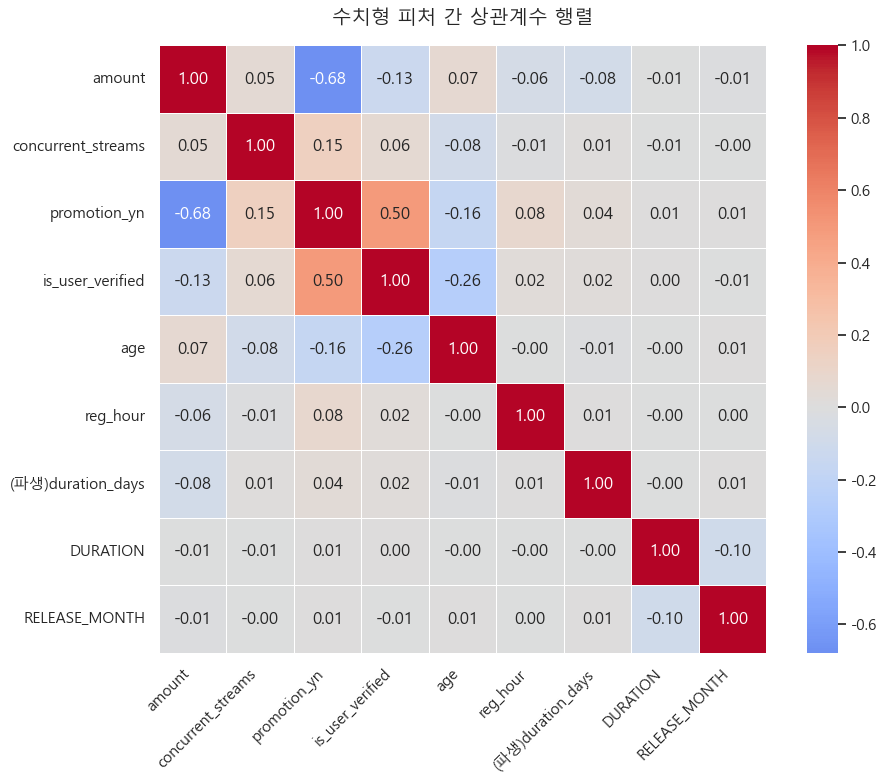

In [ ]:
df = pd.read_excel(r"final_merged(단칼)_v1.xlsx")

# 다중공선성 검토 대상 수치형 컬럼
# repurchase, is_churn_prevented는 타깃 변수이므로 제외
numeric_cols = [
    'amount',
    'concurrent_streams',
    'promotion_yn',
    'is_user_verified',
    'age',
    'reg_hour',
    '(파생)duration_days',
    'DURATION',
    'RELEASE_MONTH'
]

df_numeric = df[numeric_cols]

# 상관계수 행렬 계산
corr_matrix = df_numeric.corr()

# 히트맵 시각화
fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,          # 셀 안에 수치 표시
    fmt='.2f',           # 소수점 2자리
    cmap='coolwarm',     # 양의 상관: 빨강, 음의 상관: 파랑
    center=0,            # 0 기준으로 색상 분기
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('수치형 피처 간 상관계수 행렬', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

> 수치형 피처 간 다중공선성 검토

대상 컬럼:
1. `amount`
2. `concurrent_streams`
3. `promotion_yn`
4. `is_user_verified`
5. `age`
6. `reg_hour`
7. `(파생)duration_days`
8. `DURATION`
9. `RELEASE_MONTH`

---

타깃 변수인 `repurchase`와 `is_churn_prevented`는 검토 대상에서 제외함.  
범주형 컬럼인 `gender`, `payment_device`, `billing_method`는 수치형 변환 없이는 상관계수 산출이 불가능.  
이번 검토 범위에 포함하지 않았음.

> 주요 상관관계 쌍

**amount와 promotion_yn: -0.68**

두 컬럼 사이의 상관계수가 -0.68로 가장 높게 나타남.  
그러나 이는 다중공선성 문제가 아니라 도메인 규칙이 반영된 자연스러운 결과인듯?  
`promotion_yn`은 100원딜 적용 여부만을 나타내는 이진 변수이고,  
`amount`는 100원딜을 포함한 모든 결제 금액을 담는 수치형 변수.  

100원딜 적용자의 amount가 낮게 찍히면서 생긴 상관관계이므로,  
두 컬럼이 같은 정보를 중복으로 담고 있다고 볼 수 없다. 둘 다 유지한다.  

**promotion_yn과 is_user_verified: 0.50**

본인인증이 프로모션 수혜의 전제조건이라는 도메인 규칙에 의해 발생한 상관관계.   
0.7 미만으로 당장 제거할 수준은 아니므로 둘 다 유지하면 될듯.  
다만 모델 학습 후 피처 중요도에서 둘 중 하나가 지나치게 낮게 나올 경우 재검토 필수!

> 결론

0.7을 초과하는 쌍이 존재하지 않으며, 가장 높은 상관계수인 -0.68도 도메인 규칙으로 설명되는 자연스러운 관계다.  
수치형 컬럼들 사이에서는 다중공선성 문제가 없는 것으로 판단한다.  
 단, 범주형 컬럼들이 인코딩되어 모델에 투입된 이후 수치형 피처들과의 관계는 별도로 검토가 필요하다.